# **1. Perkenalan Dataset**


Dataset yang digunakan pada eksperimen ini adalah **RT-IoT2022** dari UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/942/rt-iot2022).

**Deskripsi Dataset**

RT-IoT2022 adalah dataset lalu lintas jaringan (network traffic) yang dibangun dari infrastruktur IoT secara real-time. Dataset ini menggabungkan pola traffic normal dari beberapa perangkat IoT (MQTT, Amazon-Alexa, ThingSpeak-LED, Wipro-Bulb) dengan pola traffic serangan (Brute-Force SSH, DDoS Hping & Slowloris, ARP Poisoning, serta berbagai jenis Nmap scanning). Data ditangkap menggunakan Zeek network monitoring tool dan plugin Flowmeter.

* **Jumlah instance**: 123.117 baris
* **Jumlah fitur**: 83 fitur numerik/kategorikal (mis. `id.orig_p`, `id.resp_p`, `proto`, `service`, `flow_duration`, `fwd_pkts_tot`, `bwd_pkts_tot`, dst.)
* **Target**: kolom `Attack_type` (multi-class) yang berisi 9 jenis serangan dan 4 pola normal
* **Sumber**: Sharmila, B. S. & Nagapadma, R. (2023). RT-IoT2022 [Dataset]. UCI Machine Learning Repository.

Task pemodelan yang dilakukan adalah **klasifikasi multi-kelas** untuk memprediksi `Attack_type` dari fitur-fitur traffic jaringan (Intrusion Detection System).

# **2. Import Library**

Pada tahap ini diimpor pustaka yang dibutuhkan: `pandas` dan `numpy` untuk manipulasi data, `matplotlib`/`seaborn` untuk visualisasi, `scikit-learn` untuk preprocessing, serta `ucimlrepo` untuk mengambil dataset langsung dari UCI ML Repository.

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')


Note: you may need to restart the kernel to use updated packages.


# **3. Memuat Dataset**

Dataset diambil langsung dari UCI ML Repository menggunakan pustaka `ucimlrepo` dengan `id=942` (RT-IoT2022). Fitur (`X`) dan target (`y`) digabung menjadi satu DataFrame, kemudian disimpan sebagai raw dataset (`namadataset_raw/rt_iot2022_raw.csv`) sebelum dianalisis lebih lanjut.

In [2]:
# Mengambil dataset RT-IoT2022 langsung dari UCI ML Repository
rt_iot2022 = fetch_ucirepo(id=942)

X = rt_iot2022.data.features
y = rt_iot2022.data.targets

df = pd.concat([X, y], axis=1)

print('Ukuran dataset:', df.shape)
df.head()

# Menyimpan dataset mentah (raw) ke folder namadataset_raw
os.makedirs('namadataset_raw', exist_ok=True)
df.to_csv('namadataset_raw/rt_iot2022_raw.csv', index=False)
print('Dataset mentah tersimpan di namadataset_raw/rt_iot2022_raw.csv')

# Informasi umum dataset
df.info()

Ukuran dataset: (123117, 84)
Dataset mentah tersimpan di namadataset_raw/rt_iot2022_raw.csv
<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  str    
 3   service                   123117 non-null  str    
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio      

# **4. Exploratory Data Analysis (EDA)**

Tujuan EDA adalah memahami karakteristik dataset sebelum masuk ke tahap preprocessing.

Jumlah kolom dengan missing values: 0
Jumlah baris duplikat: 5195
Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


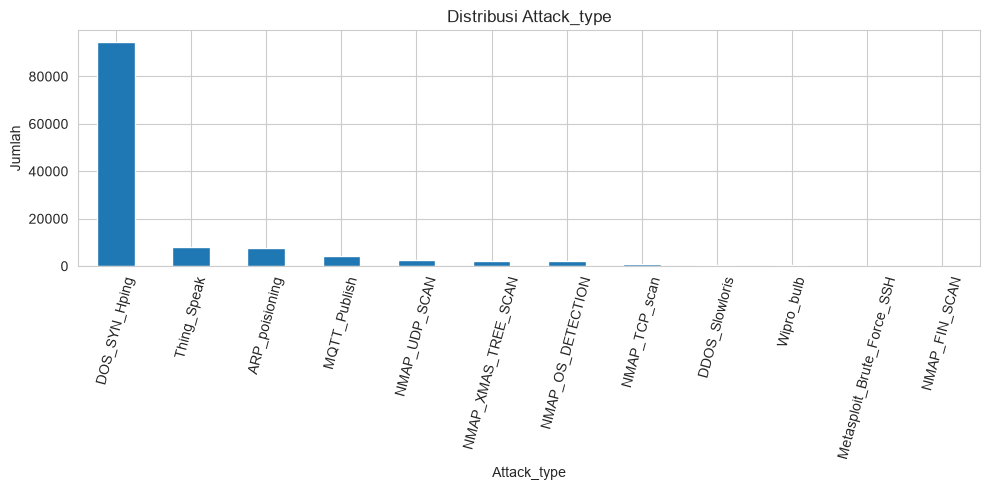

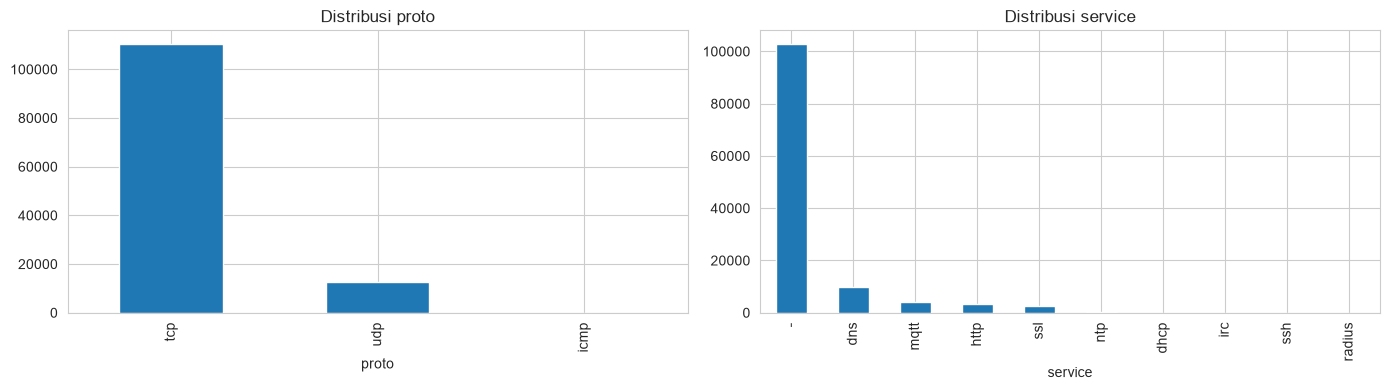

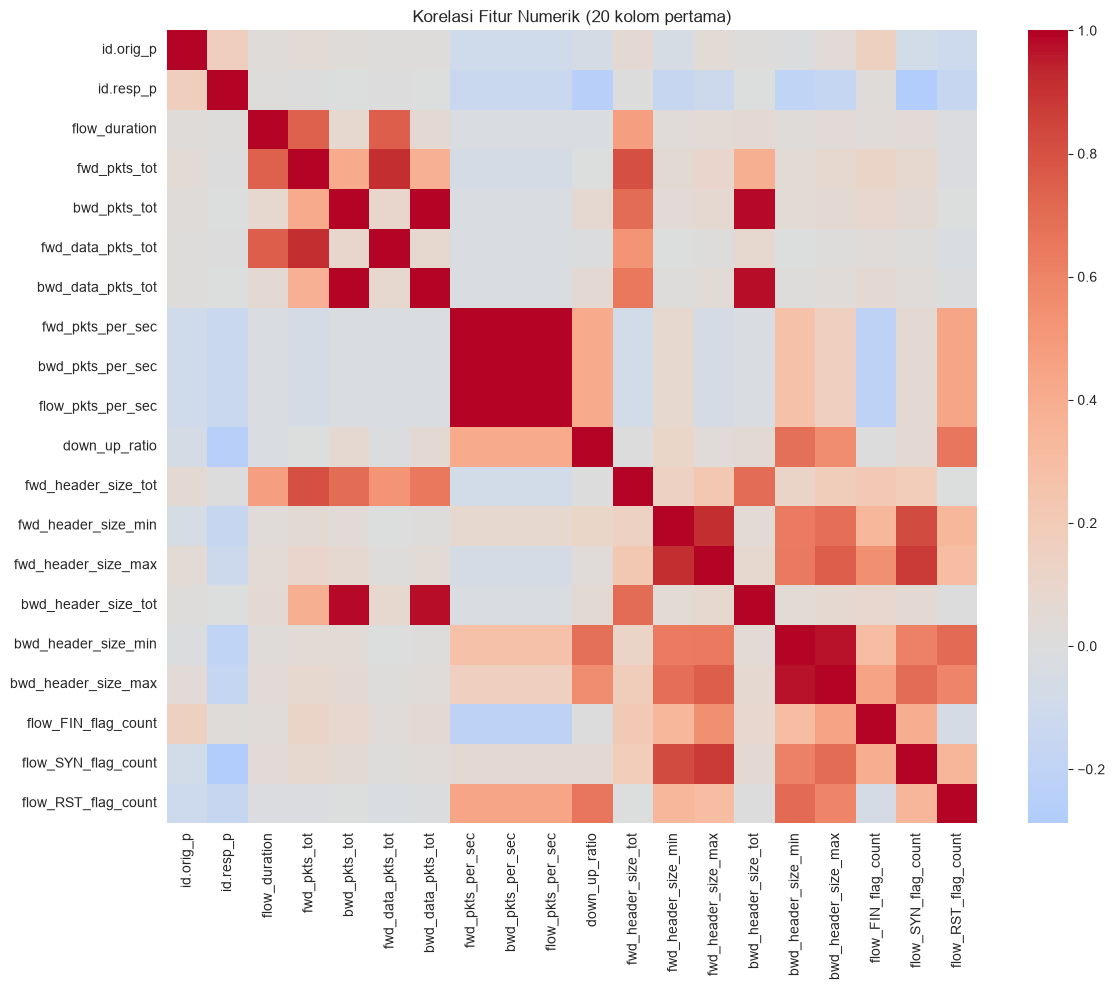

Jumlah outlier pada flow_duration: 19171 dari 123117 baris


In [3]:
# Statistik deskriptif fitur numerik
df.describe().T

# Mengecek missing values pada setiap kolom
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Jumlah kolom dengan missing values:', len(missing))
missing

# Mengecek data duplikat
print('Jumlah baris duplikat:', df.duplicated().sum())

# Distribusi kelas target (Attack_type)
target_col = 'Attack_type'
print(df[target_col].value_counts())

plt.figure(figsize=(10,5))
df[target_col].value_counts().plot(kind='bar')
plt.title('Distribusi Attack_type')
plt.ylabel('Jumlah')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Distribusi fitur kategorikal proto & service
fig, axes = plt.subplots(1, 2, figsize=(14,4))
df['proto'].value_counts().plot(kind='bar', ax=axes[0], title='Distribusi proto')
df['service'].value_counts().plot(kind='bar', ax=axes[1], title='Distribusi service')
plt.tight_layout()
plt.show()

# Korelasi antar fitur numerik (subset agar tetap terbaca)
num_cols = df.select_dtypes(include=[np.number]).columns[:20]
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Korelasi Fitur Numerik (20 kolom pertama)')
plt.tight_layout()
plt.show()

# Deteksi outlier sederhana menggunakan IQR pada flow_duration
q1 = df['flow_duration'].quantile(0.25)
q3 = df['flow_duration'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['flow_duration'] < lower) | (df['flow_duration'] > upper)]
print(f'Jumlah outlier pada flow_duration: {len(outliers)} dari {len(df)} baris')

# **5. Data Preprocessing**

Tahapan preprocessing yang dilakukan pada dataset RT-IoT2022:
1. Menghapus data duplikat
2. Menangani missing values (jika ada)
3. Encoding fitur kategorikal (`proto`, `service`) dengan Label Encoding
4. Encoding label target (`Attack_type`) dengan Label Encoding
5. Standarisasi fitur numerik dengan `StandardScaler`
6. Split data menjadi data latih dan data uji (80:20, stratified terhadap target)
7. Menyimpan dataset hasil preprocessing ke folder `preprocessing/`

In [4]:
df_clean = df.copy()

# 1. Menghapus duplikat
df_clean = df_clean.drop_duplicates()

# 2. Menangani missing values (drop baris yang masih kosong, jika ada)
df_clean = df_clean.dropna()

print('Ukuran data setelah cleaning:', df_clean.shape)

# 3 & 4. Encoding fitur kategorikal dan target
categorical_cols = ['proto', 'service']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

target_encoder = LabelEncoder()
df_clean[target_col] = target_encoder.fit_transform(df_clean[target_col])

df_clean.head()

# 5. Standarisasi fitur numerik (kecuali kolom target)
feature_cols = [c for c in df_clean.columns if c != target_col]
numeric_feature_cols = df_clean[feature_cols].select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
df_clean[numeric_feature_cols] = scaler.fit_transform(df_clean[numeric_feature_cols])

df_clean.head()

# 6. Split data latih dan data uji
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)

# 7. Menyimpan dataset hasil preprocessing
os.makedirs('preprocessing/rt_iot2022_preprocessing', exist_ok=True)

train_df = X_train.copy()
train_df[target_col] = y_train
test_df = X_test.copy()
test_df[target_col] = y_test

train_df.to_csv('preprocessing/rt_iot2022_preprocessing/train.csv', index=False)
test_df.to_csv('preprocessing/rt_iot2022_preprocessing/test.csv', index=False)

# Menyimpan gabungan data (opsional, untuk kebutuhan modelling.py yang melakukan split sendiri)
full_clean_df = pd.concat([train_df, test_df], axis=0)
full_clean_df.to_csv('preprocessing/rt_iot2022_preprocessing/rt_iot2022_clean.csv', index=False)

print('Dataset hasil preprocessing tersimpan di preprocessing/rt_iot2022_preprocessing/')


Ukuran data setelah cleaning: (117922, 84)
X_train: (94337, 83) | X_test: (23585, 83)
Dataset hasil preprocessing tersimpan di preprocessing/rt_iot2022_preprocessing/
